고유문자=53  X=(4980, 20)
Transformer 파라미터: 11,989
Epoch 1/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 13s 59ms/step - accuracy: 0.0980 - loss: 3.7185
Epoch 2/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1577 - loss: 3.1862
Epoch 3/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1880 - loss: 3.0833
Epoch 4/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2193 - loss: 2.9520
Epoch 5/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2419 - loss: 2.8398
Epoch 6/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2534 - loss: 2.7490
Epoch 7/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2634 - loss: 2.6875
Epoch 8/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2603 - loss: 2.6323
Epoch 9/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2697 - loss: 2.5988
Epoch 10/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2688 - loss: 2.5948


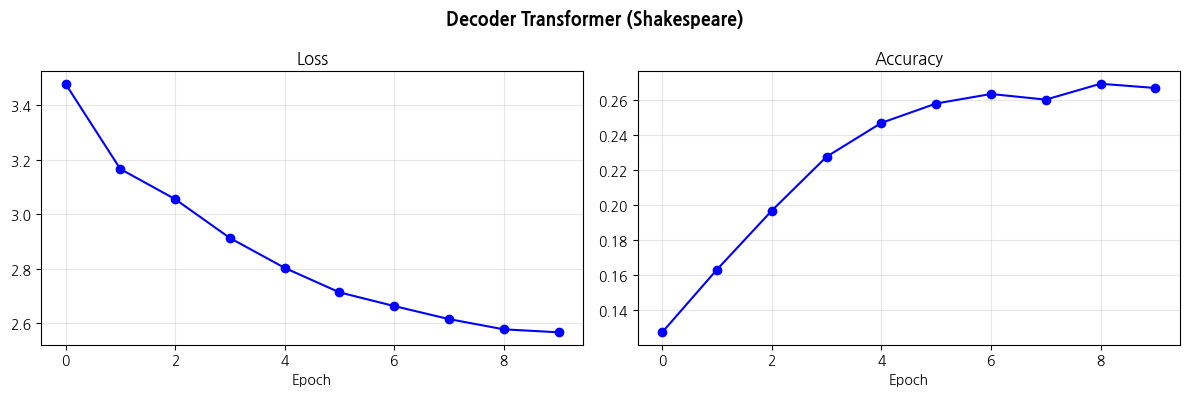


[생성 T=0.5]
ere ce us athe d t it ired the cersor t be we me deatitile me t it t y f theall the me tis theare al t tind he ctheng welll hell t g more ptore icou it coune he the t e thar t t we athe the atit nenou

Transformer  Loss: 2.5676
Transformer   Acc: 0.2667


In [1]:
# 실습 8 · Decoder-only Transformer (Shakespeare)
import sys, numpy as np, tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import koreanize_matplotlib

if "google.colab" in sys.modules:
    import subprocess
    subprocess.run(["pip", "install", "-q", "koreanize-matplotlib"], check=True)

SEED = 42;  np.random.seed(SEED);  tf.random.set_seed(SEED)

# ---- 설정 ----
SEQ_LEN    = 20
D_MODEL    = 32
N_HEADS    = 1
FF_DIM     = 64
N_LAYERS   = 1
DROPOUT    = 0.1
EPOCHS     = 10
BATCH_SIZE = 64
MAX_TOKENS = 5000

# ---- 실험 권장 (1~2개만 수정) ----
# N_LAYERS  = 2   # 레이어 수 증가 -> 표현력 향상, 속도 저하
# N_HEADS   = 2   # 헤드 수 증가  -> 다양한 참조 패턴 학습
# EPOCHS    = 20  # 에폭 증가     -> 수렴 여부 확인
# MAX_TOKENS= 2000 # 데이터 축소  -> 과적합 관찰
# DROPOUT   = 0.3 # 드롭아웃 강화 -> 정규화 효과 확인


# --- Positional Encoding ---
class PositionalEncoding(layers.Layer):
    def __init__(self, seq_len, d_model, **kwargs):
        super().__init__(**kwargs)
        pos    = np.arange(seq_len)[:, np.newaxis]
        dims   = np.arange(d_model)[np.newaxis, :]
        angles = pos / np.power(10000, (2 * (dims // 2)) / d_model)
        angles[:, 0::2] = np.sin(angles[:, 0::2])
        angles[:, 1::2] = np.cos(angles[:, 1::2])
        self.pe = tf.cast(angles[np.newaxis], dtype=tf.float32)

    def call(self, x):
        return x + self.pe[:, :tf.shape(x)[1], :]


# --- Transformer Block ---
class TransformerBlock(layers.Layer):
    def __init__(self, d_model, n_heads, ff_dim, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.mha   = layers.MultiHeadAttention(
                         num_heads=n_heads, key_dim=d_model // n_heads, dropout=dropout)
        self.ffn   = keras.Sequential([
                         layers.Dense(ff_dim, activation="relu"),
                         layers.Dense(d_model)])
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.drop1 = layers.Dropout(dropout)
        self.drop2 = layers.Dropout(dropout)

    def call(self, x, training=False):
        seq_len  = tf.shape(x)[1]
        mask     = 1 - tf.linalg.band_part(tf.ones((seq_len, seq_len)), -1, 0)
        attn_out = self.mha(x, x, x, attention_mask=mask, training=training)
        x        = self.norm1(x + self.drop1(attn_out, training=training))
        return self.norm2(x + self.drop2(self.ffn(x), training=training))


# --- 데이터 ---
path = keras.utils.get_file(
    "shakespeare.txt",
    "https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt"
)
text        = open(path).read()[:MAX_TOKENS]
chars       = sorted(set(text))
VOCAB       = len(chars)
c2i         = {c: i for i, c in enumerate(chars)}
i2c         = {i: c for c, i in c2i.items()}
encoded     = np.array([c2i[c] for c in text])

X = np.array([encoded[i:i+SEQ_LEN] for i in range(len(encoded) - SEQ_LEN)])
y = np.array([encoded[i+SEQ_LEN]   for i in range(len(encoded) - SEQ_LEN)])
print(f"고유문자={VOCAB}  X={X.shape}")


# --- 모델 : Decoder-only Transformer ---
inp = layers.Input(shape=(SEQ_LEN,))
x   = layers.Embedding(VOCAB, D_MODEL)(inp)
x   = PositionalEncoding(SEQ_LEN, D_MODEL)(x)
x   = layers.Dropout(DROPOUT)(x)
for i in range(N_LAYERS):
    x = TransformerBlock(D_MODEL, N_HEADS, FF_DIM, DROPOUT, name=f"tb_{i}")(x)
x   = layers.Lambda(lambda t: t[:, -1, :])(x)
out = layers.Dense(VOCAB, activation="softmax")(x)

model_tf = keras.Model(inp, out)
model_tf.compile(optimizer="adam",
                 loss="sparse_categorical_crossentropy",
                 metrics=["accuracy"])

print(f"Transformer 파라미터: {model_tf.count_params():,}")


# --- 학습 ---
h = model_tf.fit(X, y, epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=1)


# --- 시각화 : 학습 곡선 ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
for ax, key, title in [(ax1, "loss", "Loss"), (ax2, "accuracy", "Accuracy")]:
    ax.plot(h.history[key], "b-o")
    ax.set(title=title, xlabel="Epoch");  ax.grid(True, alpha=0.3)
plt.suptitle("Decoder Transformer (Shakespeare)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig08_curves.png", dpi=150, bbox_inches="tight");  plt.show()


# --- 생성 함수 ---
def generate(model, seed, length=200, temperature=0.5):
    result = list(seed)
    seq    = [c2i[c] for c in seed[-SEQ_LEN:]]
    for _ in range(length):
        probs  = model.predict(np.array([seq[-SEQ_LEN:]]), verbose=0)[0]
        logits = np.log(probs + 1e-10) / temperature
        exp_l  = np.exp(logits);  adj = exp_l / exp_l.sum()
        idx    = np.random.choice(len(adj), p=adj)
        result.append(i2c[idx]);  seq.append(idx)
    return "".join(result[SEQ_LEN:])

seed = text[:SEQ_LEN]
print(f"\n[생성 T=0.5]\n{generate(model_tf, seed)}")


# --- 결과 ---
print(f"\nTransformer  Loss: {h.history['loss'][-1]:.4f}")
print(f"Transformer   Acc: {h.history['accuracy'][-1]:.4f}")